In [ ]:
!pip install scikit-learn pandas numpy urduhack


INFO: pip is looking at multiple versions of tf2crf to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tf2crf to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.0/98.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.8/82.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 19.7 MB/s eta 0:00:00
  Attempting uninstall: Click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
  Attempting uninstall: tensorflow-datasets
    Found existing installation: tensorfl

In [ ]:
%pip install urduhack

In [ ]:
# Initialize UrduHack
import urduhack
urduhack.download()

36788015/36788015 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Urdu Text Preprocessing + Naive Bayes Classifier

import re
import string
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
import urduhack

In [ ]:
import pandas as pd
df = pd.read_excel("/content/sample_data/UHSCD 13k.xlsx")
df.to_csv("UHSCD 13k.csv", index=False, encoding='utf-8')

# Set pandas option to display full column width
# pd.set_option('display.max_colwidth', None)

df = pd.read_csv("UHSCD 13k.csv")
display(df.head())
display(df['label'].value_counts())

,tweets,label
0,شیعہ کائنات کا بدترین کافر ہے، میر پور خاص چہل...,1
1,جو امام علی رضی اللہ تعالی عنہ کی محبّت میں ات...,1
2,یاد ماضی عزاب یے یا رب چھین لے مجھ سے حافظہ میرا,0
3,‎‎ صحابہ معیارحق ہیں، یہ شیعہ جب تک صحابہ پر ...,1
4,فلسطین کے ساتھ ڈٹ جانے والا ٹائیگر,0


,count
label,
1,6985
0,6142


In [ ]:
# import pandas as pd
# df = pd.read_excel("/content/sample_data/Labelled Dataset 13k.xlsx")
# df.to_csv("Labelled Dataset 13k.csv", index=False, encoding='utf-8')
# display(df.head())
# display(df['label'].value_counts())

In [ ]:
# Display the first 10 sentences from the 'clean_text' column
# print("First 10 cleaned tweets:")
# for i, tweet in enumerate(df["clean_text"].head(10)):
#     print(f"{i+1}: {tweet}")

In [ ]:
# hate_tweet = df[df.label == 1]
# hate_tweet.head()

In [ ]:
# hate_tweet = df[df.label == 0]
# hate_tweet.head()

In [ ]:
# # Calculate the percentage of each label in the filtered DataFrame
# label_percentages = df_filtered_stat['label'].value_counts(normalize=True) * 100

# # Format and print the output
# print("Label percentage:")
# for label, percentage in label_percentages.items():
#     print(f"Label {label}: {percentage:.2f}%")

In [ ]:
# Urdu Preprocessing Function
import urduhack
from urduhack.tokenization import word_tokenizer

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Remove Urdu diacritics (زبر، زیر، پیش)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    # Remove Urdu & English digits
    text = re.sub(r'[0-9۰-۹]', '', text)
    # Remove punctuation and symbols
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
     # Remove stop words (using a basic list for demonstration)
    # You might need a more comprehensive list or a dedicated library for Urdu stop words
    stop_words = set(["کے", "کا", "کی", "میں", "ہے", "اور", "کو", "سے", "پر", "ہیں", "تھا", "تھی", "تھے", "گا", "گی", "گے", "یہ", "وہ", "اس", "ان", "ایک", "ہو", "ہوا", "ہوئی", "ہوئے", "کر", "کیا", "کیوں", "کب", "کیسے", "کہاں", "جس", "جن", "جو"])
    words = text.split()
    text = " ".join([word for word in words if word not in stop_words])

    return text.strip()


# Apply preprocessing
df["clean_text"] = df["tweets"].apply(preprocess_text)

# Filter out rows where 'label' is not 0 or 1 and convert 'label' to integer
df_filtered = df[df['label'].isin([0, 1])].copy()
df_filtered['label'] = df_filtered['label'].astype(int)

In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
# count_vect = CountVectorizer(stop_words='Urdu')
# transformer = TfidfTransformer(norm='l2',sublinear_tf=True)

In [ ]:
df["clean_text"] = df["tweets"].apply(preprocess_text)
display(df[["tweets", "label", "clean_text"]].head())

,tweets,label,clean_text
0,شیعہ کائنات کا بدترین کافر ہے، میر پور خاص چہل...,1,شیعہ کائنات بدترین کافر میر پور خاص چہلم ویڈیو...
1,جو امام علی رضی اللہ تعالی عنہ کی محبّت میں ات...,1,امام علی رضی اللہ تعالی عنہ محبت اتنا آگے بڑھ ...
2,یاد ماضی عزاب یے یا رب چھین لے مجھ سے حافظہ میرا,0,یاد ماضی عزاب یے یا رب چھین لے مجھ حافظہ میرا
3,‎‎ صحابہ معیارحق ہیں، یہ شیعہ جب تک صحابہ پر ...,1,صحابہ معیارحق شیعہ جب تک صحابہ بھونکتے رہیں ہم...
4,فلسطین کے ساتھ ڈٹ جانے والا ٹائیگر,0,فلسطین ساتھ ڈٹ جانے والا ٹائیگر


In [ ]:
#  Tokenization + TF-IDF Vectorization

# vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
# X = vectorizer.fit_transform(df_filtered["clean_text"])
# y = df_filtered["label"]

In [ ]:
# import re
# token_pattern = r"(?u)\b\w+\b"

# # Apply the token pattern to the first few cleaned tweets and display the list of tokens
# print("First 5 cleaned tweets tokenized:")
# for tweet in df_filtered["clean_text"].head():
#     tokens = re.findall(token_pattern, tweet)
#     print(tokens)

In [ ]:
# this is also a tokinization method
# def process_tweet(tweet):
#     return " ".join(re.sub("(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])", " ",tweet.lower()).split())

In [ ]:
# # Filter out rows where 'label' is not 0 or 1 after preprocessing
# df_filtered_oversample = df[df['label'].isin([0, 1])].copy()

# # #As this dataset is highly imbalance we have to balance this by over sampling
# cnt_non_fraud = df_filtered_oversample[df_filtered_oversample['label'] == 0]['clean_text'].count()
# df_class_fraud = df_filtered_oversample[df_filtered_oversample['label'] == 1]
# df_class_nonfraud = df_filtered_oversample[df_filtered_oversample['label'] == 0]
# df_class_fraud_oversample = df_class_fraud.sample(cnt_non_fraud, replace=True)
# df_oversampled = pd.concat([df_class_nonfraud, df_class_fraud_oversample], axis=0)

# print('Random over-sampling:')
# print(df_oversampled['label'].value_counts())

In [ ]:
# Feature Extraction (TF-IDF + n-gram(ngram_range=(1,2), max_features=8000))
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=8000)
X = vectorizer.fit_transform(df_filtered["clean_text"])
y = df_filtered["label"]

In [ ]:
#  Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
nb = MultinomialNB()
nb.fit(X_train, y_train)

# #Building Navie Bayes Model
# from sklearn.naive_bayes import MultinomialNB
# model = MultinomialNB()
# model.fit(X_train, y_train)


MultinomialNB()

In [ ]:
# Accuracy on test set for 90/10  without balance data
y_pred_nb = nb.predict(X_test) # Define y_pred_nb here
print("NB Model Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

NB Model Performance:
Test Accuracy: 0.8339680121858339

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.81       598
           1       0.81      0.90      0.86       715

    accuracy                           0.83      1313
   macro avg       0.84      0.83      0.83      1313
weighted avg       0.84      0.83      0.83      1313



Accuracy: 0.8339680121858339

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.81       598
           1       0.81      0.90      0.86       715

    accuracy                           0.83      1313
   macro avg       0.84      0.83      0.83      1313
weighted avg       0.84      0.83      0.83      1313



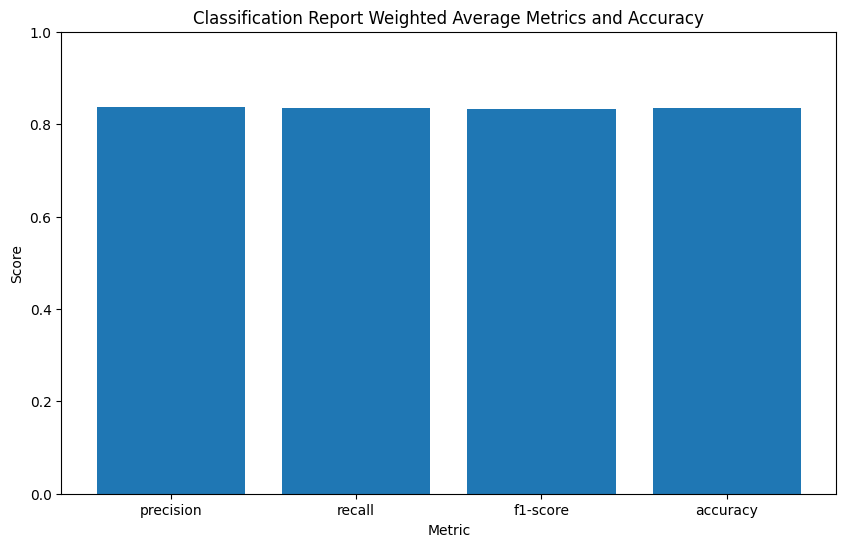

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

y_pred = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Convert the classification report to a pandas DataFrame for easier plotting
report_df = pd.DataFrame(report).transpose()

# Extract weighted averages
weighted_avg_metrics = report_df.loc['weighted avg', ['precision', 'recall', 'f1-score']]

# Create a new DataFrame for plotting the weighted averages
plot_df_weighted = pd.DataFrame({
    'Metric': weighted_avg_metrics.index,
    'Score': weighted_avg_metrics.values
})

# Add accuracy to the plot_df_weighted
accuracy_score_value = accuracy_score(y_test, y_pred)
plot_df_weighted = pd.concat([plot_df_weighted, pd.DataFrame({'Metric': ['accuracy'], 'Score': [accuracy_score_value]})], ignore_index=True)


# Plot the weighted average metrics and accuracy
plt.figure(figsize=(10, 6))
plt.bar(plot_df_weighted['Metric'], plot_df_weighted['Score'])
plt.title('Classification Report Weighted Average Metrics and Accuracy')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for scores
plt.show()

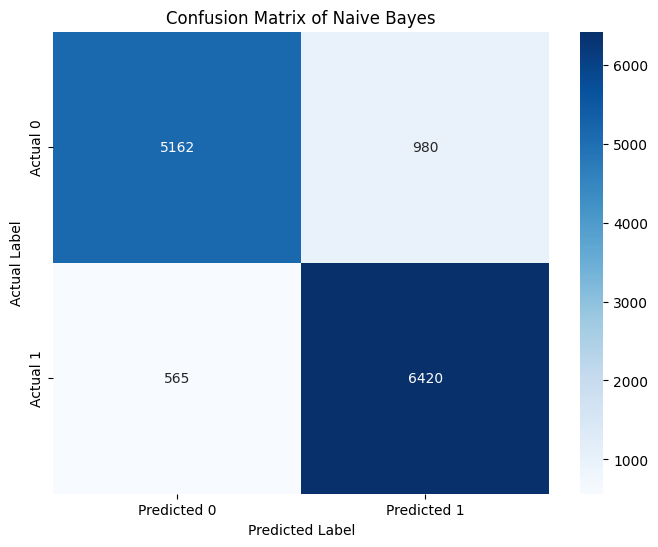

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Transform the entire dataset using the fitted vectorizer
X_full_transformed = vectorizer.transform(df_filtered["clean_text"])

# Get predictions for the entire dataset
y_full_pred = nb.predict(X_full_transformed)

# Generate the confusion matrix
cm = confusion_matrix(df_filtered["label"], y_full_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix of Naive Bayes')
plt.show()

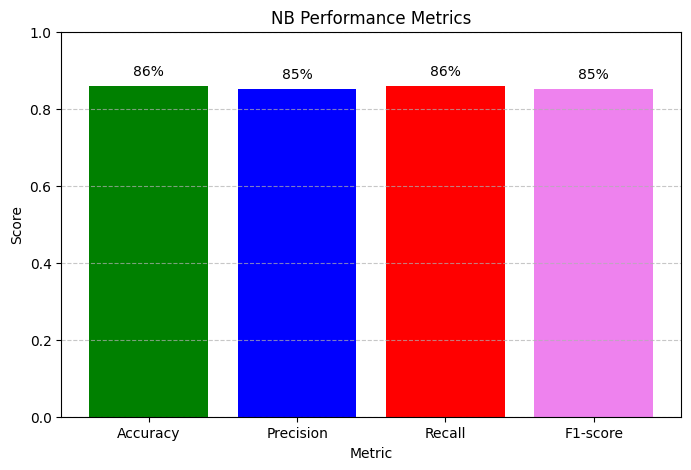

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Provided values
accuracy = 0.86
precision = 0.85
recall = 0.86
f1_score = 0.85

# Create a DataFrame for plotting
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [accuracy, precision, recall, f1_score]
}
plot_df = pd.DataFrame(metrics_data)

# Plot the metrics
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df['Metric'], plot_df['Score'], color=['green', 'blue', 'red', 'violet'])
plt.title('NB Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.0%}', ha='center', va='bottom')

plt.show()

In [ ]:
# import pandas as pd
# df = pd.read_excel("new data.xlsx")
# df.to_csv("new data.csv", index=False, encoding='utf-8')
# df.head()

In [ ]:
# # transform your cleaned test data into a numerical format for model understanding.

# df_tested = df.copy()
# df_tested["clean_text"] = df_tested["tweets"].apply(preprocess_urdu)
# X_test_transformed = vectorizer.transform(df_tested['clean_text'])

In [ ]:
# # printed the predicted data


# df_tested['predicted_label_nb'] = model.predict(X_test_transformed)
# display(df_tested[["tweets", "label", "predicted_label_nb"]].head())

In [ ]:
# created the test predictions Analysis csv

# file_name = 'test_predictions_Analysis.csv'
# df_tested.to_csv(file_name,index=False)

In [ ]:
# # created the chart for analysis of predicted tweets

# import matplotlib.pyplot as plt
# import pandas as pd
# from sklearn.metrics import accuracy_score, classification_report

# # Use the df_tested DataFrame which contains the 'predicted_label' column
# predictions_df = df_tested

# # Count the occurrences of each original and predicted label
# original_label_counts = predictions_df['label'].value_counts().sort_index()
# predicted_label_counts = predictions_df['predicted_label_nb'].value_counts().sort_index()

# # Combine the indices to ensure all labels are present in the plot
# all_labels = original_label_counts.index.union(predicted_label_counts.index)

# # Create a DataFrame for plotting, reindexing to include all labels
# plot_df = pd.DataFrame({
#     'Original Labels': original_label_counts.reindex(all_labels, fill_value=0),
#     'Predicted Labels': predicted_label_counts.reindex(all_labels, fill_value=0)
# })

# # Create a bar chart
# plt.figure(figsize=(8, 5))
# plot_df.plot(kind='bar', ax=plt.gca())
# plt.title('Comparison of Original and Predicted Label Distribution')
# plt.xlabel('Label')
# plt.ylabel('Count')
# plt.xticks(rotation=0)
# plt.legend(title='Label Type')
# plt.show()

# # Calculate and print accuracy for Naive Bayes
# accuracy_nb = accuracy_score(df_tested['label'], df_tested['predicted_label_nb'])
# print(f"Naive Bayes Accuracy on Test Data: {accuracy_nb:.4f}")

# # Print Classification Report
# print("\nClassification Report:\n", classification_report(df_tested['label'], df_tested['predicted_label_nb'], zero_division=0))